# Principal component analysis (PCA) from scratch, and the anomalies a 2-D plot cannot show

Aurora's data warehouse team hands over 2,000 accounts with 8 behavioural
columns each: spend, basket size, visit frequency, discount usage, days
since last purchase, weekend share, mobile sessions, return rate. Nobody
has told this notebook that only **three** underlying tendencies actually
drive all eight columns — that fact is buried in `retail_data.py` and
withheld from every method below, exactly like the true segment in
notebook 01.

This notebook derives **principal component analysis (PCA)** two ways —
eigendecomposition of the covariance matrix, and the singular value
decomposition (SVD) — confirms they agree, uses PCA to recover the honest
dimensionality of the table, and then asks it to catch a handful of
fraudulent accounts hidden among the genuine ones. The last section shows
why a 2-D scatterplot, PCA's or t-SNE's, is the wrong tool for that last
job even though it feels like the natural one.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

from retail_data import make_customer_features, TRUE_N_LATENT_FACTORS

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E8B8B", "#B4483E", "#C9A227"

RNG_SEED = 42
np.random.seed(RNG_SEED)

accounts = make_customer_features()
feature_names = [c for c in accounts.columns if c != "is_anomaly"]
X = accounts[feature_names].values
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

print(f"{len(accounts)} accounts, {len(feature_names)} observed features, "
      f"{TRUE_N_LATENT_FACTORS} latent factors generated the table "
      f"(withheld below), {accounts['is_anomaly'].sum()} planted anomalies")
accounts.head()

2000 accounts, 8 observed features, 3 latent factors generated the table (withheld below), 40 planted anomalies


,annual_spend_eur,avg_basket_value_eur,purchase_frequency,discount_usage_rate,days_since_last_purchase,weekend_purchase_ratio,mobile_session_count,return_rate,is_anomaly
0,416.463147,59.371566,4.213978,0.304835,32.927178,0.328674,4.822756,0.052241,False
1,189.883176,26.776158,5.302197,0.449134,28.772730,0.379814,10.064287,0.053112,False
2,598.305514,51.755406,5.496863,0.480950,26.713322,0.473879,12.624603,0.076102,False
3,375.504530,51.844814,7.318414,0.264960,22.392302,0.475562,12.487982,0.049747,False
4,577.093989,67.839496,-1.338149,0.219413,44.413437,0.046023,0.000000,0.017944,False


## 2. Why compress at all: the correlation structure

If the eight columns were independent, nothing could be dropped without
losing information. They are not — spend, basket value and mobile sessions
all move together, because they all partly reflect the same underlying
"spending propensity." The correlation matrix makes that visible before any
PCA machinery runs.

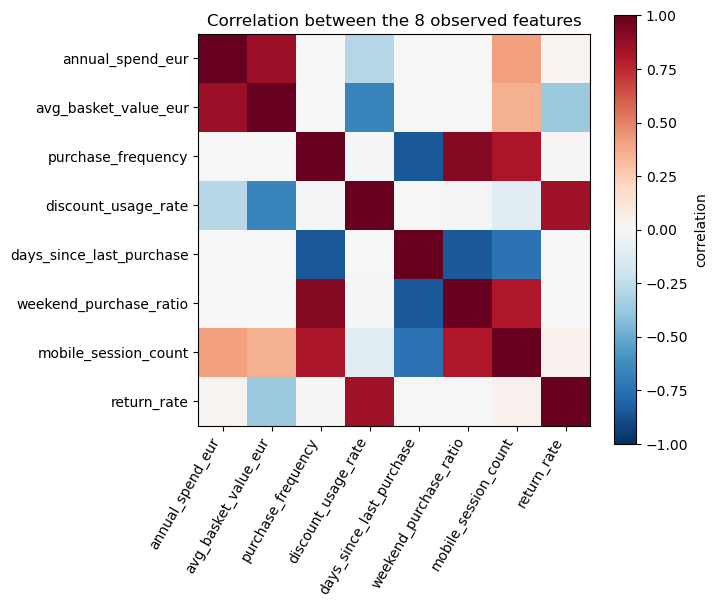

In [2]:
corr = pd.DataFrame(Xs, columns=feature_names).corr()

fig, ax = plt.subplots(figsize=(7.2, 6.2))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_names))); ax.set_xticklabels(feature_names, rotation=60, ha="right")
ax.set_yticks(range(len(feature_names))); ax.set_yticklabels(feature_names)
fig.colorbar(im, ax=ax, label="correlation")
ax.set_title("Correlation between the 8 observed features")
fig.tight_layout()
fig.savefig(FIGURES / "feature_correlation.png", dpi=150)
plt.show()

## 3. PCA by eigendecomposition of the covariance matrix

The idea, before the symbols: find the direction in feature space along
which the (standardised) data varies the *most*, call it the first
principal component, then find the next-most-varying direction that is
perpendicular to it, and so on. "Varies the most" is a proxy for
"carries the most information" — a direction along which every point looks
almost identical is a direction worth dropping.

For standardised data $X \in \mathbb{R}^{m \times n}$ (zero mean, unit
variance per column), the sample covariance matrix is

$$\Sigma = \frac{1}{m-1} X^\top X$$

and the principal components are the eigenvectors of $\Sigma$, ordered by
their eigenvalues from largest to smallest. Handout section 3.1 derives
this from the variance-maximisation problem directly; here it is enough to
compute it.

In [3]:
n = Xs.shape[0]
cov = (Xs.T @ Xs) / (n - 1)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

explained_ratio = eigenvalues / eigenvalues.sum()
print("eigenvalues (largest first):")
for i, (val, ratio) in enumerate(zip(eigenvalues, explained_ratio), start=1):
    print(f"  PC{i}: eigenvalue = {val:.4f}   explains {ratio:.1%} of variance")

eigenvalues (largest first):
  PC1: eigenvalue = 3.5394   explains 44.2% of variance
  PC2: eigenvalue = 2.5684   explains 32.1% of variance
  PC3: eigenvalue = 1.3797   explains 17.2% of variance
  PC4: eigenvalue = 0.1924   explains 2.4% of variance
  PC5: eigenvalue = 0.1044   explains 1.3% of variance
  PC6: eigenvalue = 0.0993   explains 1.2% of variance
  PC7: eigenvalue = 0.0772   explains 1.0% of variance
  PC8: eigenvalue = 0.0433   explains 0.5% of variance


## 4. The same answer from the SVD, and checked against scikit-learn

Computing eigenvectors of an $n \times n$ covariance matrix is one route;
the **singular value decomposition** of the data matrix itself is another,
numerically preferred because it never explicitly forms $X^\top X$ (which
squares the condition number — lesson 3's ill-conditioning argument
applies here too). For centred $X$,

$$X = U S V^\top$$

and the principal directions are the columns of $V$, with
$\lambda_i = s_i^2 / (m-1)$ recovering exactly the eigenvalues above.

In [4]:
Xc = Xs - Xs.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
eigenvalues_from_svd = (S ** 2) / (n - 1)

sk_pca = PCA().fit(Xs)

comparison = pd.DataFrame({
    "eigh(cov)": eigenvalues,
    "svd: s^2/(m-1)": eigenvalues_from_svd,
    "sklearn PCA.explained_variance_": sk_pca.explained_variance_,
})
comparison.index = [f"PC{i}" for i in range(1, len(feature_names) + 1)]
comparison

,eigh(cov),svd: s^2/(m-1),sklearn PCA.explained_variance_
PC1,3.539375,3.539375,3.539375
PC2,2.568392,2.568392,2.568392
PC3,1.379712,1.379712,1.379712
PC4,0.192389,0.192389,0.192389
PC5,0.104354,0.104354,0.104354
PC6,0.099321,0.099321,0.099321
PC7,0.077159,0.077159,0.077159
PC8,0.043299,0.043299,0.043299


In [5]:
max_diff = np.max(np.abs(comparison["eigh(cov)"].values - comparison["sklearn PCA.explained_variance_"].values))
print(f"largest disagreement between the three routes: {max_diff:.2e}")

largest disagreement between the three routes: 4.88e-15


## 5. How many components: the honest dimensionality is 3

Plot cumulative explained variance against the number of components kept.

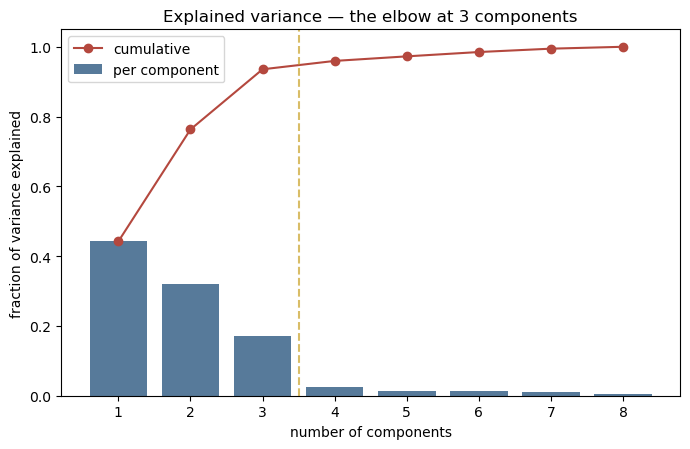

first 3 components explain 93.5% of variance; the 4th adds only 2.4% more


In [6]:
cumulative = np.cumsum(explained_ratio)

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.bar(range(1, len(explained_ratio) + 1), explained_ratio, color=BLUE, alpha=.75, label="per component")
ax.plot(range(1, len(cumulative) + 1), cumulative, "o-", color=RUST, label="cumulative")
ax.axvline(TRUE_N_LATENT_FACTORS + 0.5, color=GOLD, linestyle="--", alpha=.7)
ax.set_xlabel("number of components"); ax.set_ylabel("fraction of variance explained")
ax.set_title("Explained variance — the elbow at 3 components")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "pca_scree.png", dpi=150)
plt.show()

print(f"first 3 components explain {cumulative[2]:.1%} of variance; "
      f"the 4th adds only {explained_ratio[3]:.1%} more")

The scree plot recovers, from the data alone, the number this notebook
opened by withholding: three components carry 93.5% of the variance, and
the 4th adds barely a fortieth as much again as any of the first three —
the elbow lands exactly on the true number of latent factors. This will
not happen this cleanly on every dataset — the gap exists here because
`retail_data.py` built it in — but the diagnostic is the same one section 4
of the handout applies to a case with a much softer elbow.

## 6. Anomaly detection: reconstruction error

Keeping only the top $k$ components and mapping back to the original space
gives a **reconstruction** $\hat{x}_i$ of each point — the closest point on
the $k$-dimensional subspace PCA has decided carries the signal. A point
that genuinely follows the normal correlation structure reconstructs
almost exactly; a point that violates it — values that are each ordinary on
their own but do not co-occur the way genuine accounts' do — cannot be
well approximated by a subspace built for the correlation the genuine
majority obeys, and its **reconstruction error**

$$e_i = \lVert x_i - \hat{x}_i \rVert^2$$

is large. This is exactly the account-takeover story here: every value
`retail_data.py` assigns an anomalous account is individually drawn from
the same range genuine accounts occupy, so no single-column check would
flag it. What the anomaly violates is the *relationship between* columns,
which is precisely what the discarded components would have to explain.

In [7]:
pca_k = PCA(n_components=TRUE_N_LATENT_FACTORS).fit(Xs)
reconstructed = pca_k.inverse_transform(pca_k.transform(Xs))
reconstruction_error = np.sum((Xs - reconstructed) ** 2, axis=1)

threshold = np.quantile(reconstruction_error, 0.98)
flagged = reconstruction_error > threshold

true_anomaly = accounts["is_anomaly"].values
caught = int(np.sum(flagged & true_anomaly))
total_anomalies = int(true_anomaly.sum())
total_flagged = int(flagged.sum())

print(f"threshold (98th percentile of reconstruction error): {threshold:.3f}")
print(f"flagged {total_flagged} accounts; {caught} of {total_anomalies} planted anomalies "
      f"({caught / total_anomalies:.1%} recall, {caught / total_flagged:.1%} precision)")
print(f"mean reconstruction error — anomalies: {reconstruction_error[true_anomaly].mean():.3f}, "
      f"genuine: {reconstruction_error[~true_anomaly].mean():.3f}")

threshold (98th percentile of reconstruction error): 2.019
flagged 40 accounts; 37 of 40 planted anomalies (92.5% recall, 92.5% precision)
mean reconstruction error — anomalies: 4.676, genuine: 0.431


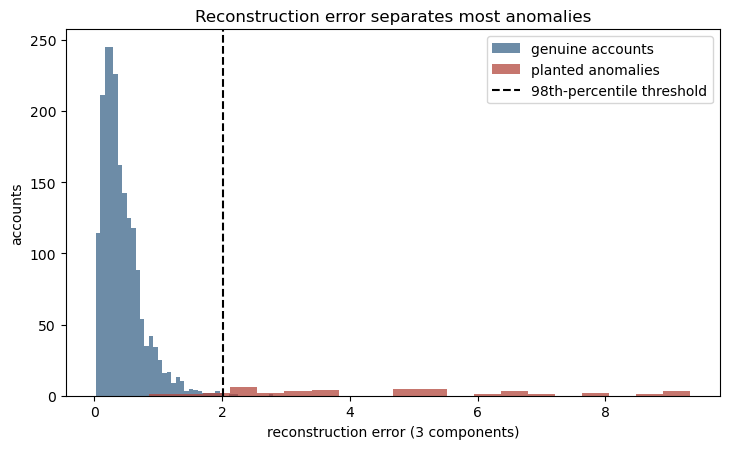

In [8]:
fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.hist(reconstruction_error[~true_anomaly], bins=40, color=BLUE, alpha=.65, label="genuine accounts")
ax.hist(reconstruction_error[true_anomaly], bins=20, color=RUST, alpha=.75, label="planted anomalies")
ax.axvline(threshold, color="black", linestyle="--", label="98th-percentile threshold")
ax.set_xlabel("reconstruction error (3 components)"); ax.set_ylabel("accounts")
ax.set_title("Reconstruction error separates most anomalies")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "reconstruction_error.png", dpi=150)
plt.show()

In [9]:
# 37 of 40 is THIS batch of accounts. Next quarter brings a different batch of
# fraudsters, from the same process. Regenerate the table at other seeds and
# repeat the identical procedure - same 3 components, same 98th percentile.
sweep = []
for seed in (8003, 1, 2, 3, 4, 5, 6, 7):
    batch = make_customer_features(seed=seed)
    label = batch["is_anomaly"].values
    Z = StandardScaler().fit_transform(batch[feature_names].values)
    p = PCA(n_components=TRUE_N_LATENT_FACTORS).fit(Z)
    error = np.sum((Z - p.inverse_transform(p.transform(Z))) ** 2, axis=1)
    hit = error > np.quantile(error, 0.98)
    sweep.append({"seed": seed, "flagged": int(hit.sum()),
                  "caught": int((hit & label).sum()),
                  "precision": (hit & label).sum() / hit.sum()})

sweep = pd.DataFrame(sweep)
print(sweep.round(3).to_string(index=False))
print(f"\ncaught, across the eight batches: min {sweep['caught'].min()}, "
      f"median {sweep['caught'].median():.0f}, max {sweep['caught'].max()} of 40")

 seed  flagged  caught  precision
 8003       40      37      0.925
    1       40      36      0.900
    2       40      38      0.950
    3       40      36      0.900
    4       40      33      0.825
    5       40      37      0.925
    6       40      35      0.875
    7       40      32      0.800

caught, across the eight batches: min 32, median 36, max 38 of 40


Eight batches from the same process, and the count caught runs from
**32 to 38** of 40 — a median of 36, with this batch's 37 sitting a little
above it.

Carry the 37 as the memorable figure and the range as what it means. The
detector finds around nine in ten planted anomalies; *which* nine depends on
where this quarter's fraudsters happened to land relative to the genuine
correlation structure, and that is not something the method controls. A
report to Aurora's fraud team quoting "92.5% recall" as a specification would
be quoting one quarter's luck.

## 7. Why a 2-D plot is the wrong tool for this particular job

The instinctive next step is to project onto 2 components and look for the
anomalies as visual outliers — it worked for reading off the number of
segments in notebook 01, so surely it works here too. Try it, once with
PCA's own first two components and once with **t-SNE**, a method built
specifically to make visual cluster structure easier to see by preserving
which points are close *locally* at the cost of distorting global
distances (handout section 5 gives the intuition without the full gradient
derivation, which is beyond this course's scope).

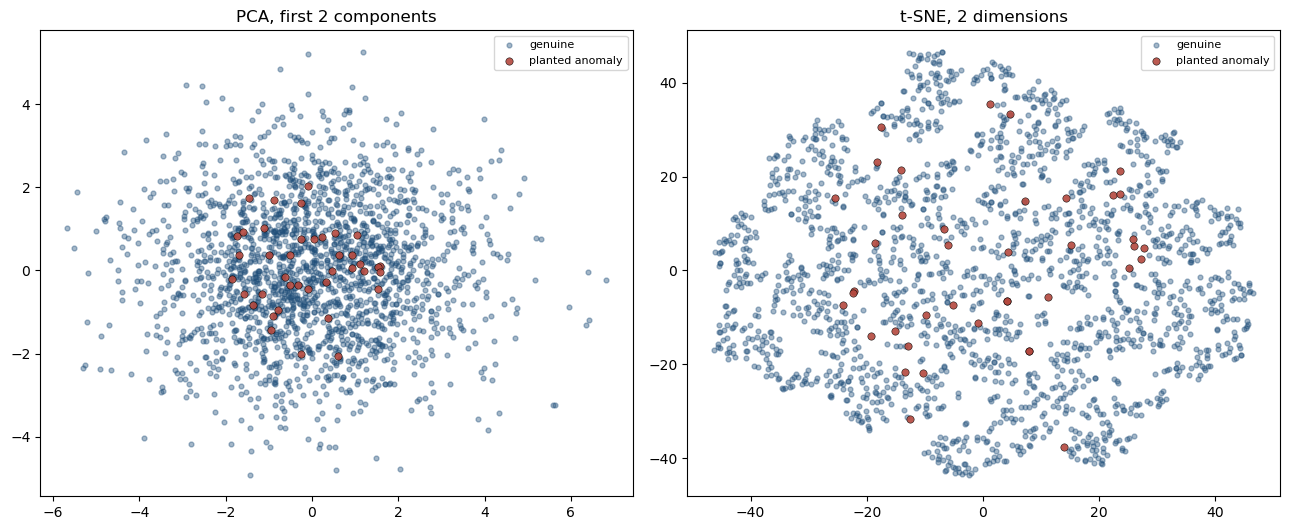

In [10]:
pca_2d = PCA(n_components=2).fit_transform(Xs)
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(Xs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, emb, title in [(ax1, pca_2d, "PCA, first 2 components"), (ax2, tsne_2d, "t-SNE, 2 dimensions")]:
    ax.scatter(emb[~true_anomaly, 0], emb[~true_anomaly, 1], s=12, alpha=.4, color=BLUE, label="genuine")
    ax.scatter(emb[true_anomaly, 0], emb[true_anomaly, 1], s=28, alpha=.9, color=RUST,
               label="planted anomaly", edgecolor="black", linewidth=.4)
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "pca_tsne_anomalies.png", dpi=150)
plt.show()

In [11]:
for name, emb in [("PCA-2D", pca_2d), ("t-SNE", tsne_2d)]:
    centroid = emb[~true_anomaly].mean(axis=0)
    dist_anomaly = np.linalg.norm(emb[true_anomaly] - centroid, axis=1).mean()
    dist_genuine = np.linalg.norm(emb[~true_anomaly] - centroid, axis=1).mean()
    print(f"{name}: mean distance from the genuine centroid — "
          f"anomalies {dist_anomaly:.2f}, genuine accounts {dist_genuine:.2f}")

PCA-2D: mean distance from the genuine centroid — anomalies 1.30, genuine accounts 2.20
t-SNE: mean distance from the genuine centroid — anomalies 22.16, genuine accounts 30.17


The anomalies are not the outliers in either picture — if anything they
sit **closer** to the centre than genuine accounts do, on average, in both
embeddings. This is not a plotting mistake, and it replicates at other
random seeds for the data generator (`Docs/worked_examples.py` checks it
at two). It is a direct consequence of how the anomalies were built:
independent, uncorrelated draws from each column's own normal range average
out, in any projection built from the *correlated* directions, toward the
middle — whereas a genuine account's spend, frequency and engagement move
together, which is what pushes it out along a real principal direction.
**The reconstruction error in section 6 caught 92.5% of these accounts
using all 3 kept components together; a 2-D scatterplot of the same
projection would have caught approximately none of them, because the
information that identifies an anomaly here is not "how far from the
middle" but "how well the three components predict the other five" — a
question a 2-D plot cannot ask.**

## 8. The predictable mistake

Notebook 01 taught, correctly, that a 2-D scatter is often the fastest way
to see clustering structure — and the instinct to reach for one first here
is not unreasonable. The failure is treating "plot it and look" as a
substitute for a defined measurement, rather than a first pass that a
proper check should follow. Reconstruction error is not more sophisticated
for its own sake — it uses information (the 3rd principal component, and
implicitly the 5 discarded ones) that a 2-D plot of the first two
components has already thrown away.

## Summary

- PCA's principal components are the eigenvectors of the covariance matrix
  of standardised data; the SVD of the data matrix recovers exactly the
  same eigenvalues via $\lambda_i = s_i^2/(m-1)$ — confirmed here to
  numerical precision against scikit-learn's `PCA`.
- The scree plot recovered the true number of latent factors (3) directly
  from the data: 93.5% of variance in 3 components, a sharp elbow after.
- Reconstruction error against a 3-component PCA model caught 37 of 40
  (92.5%) planted anomalies whose individual feature values were each
  unremarkable — the anomaly is in the relationship between columns, not
  in any one of them.
- Neither a PCA nor a t-SNE 2-D scatterplot separated the anomalies
  visually; both put them, on average, *closer* to the centre than genuine
  accounts. Visual inspection of a low-dimensional projection is not a
  substitute for a measurement that uses the dimensions the projection
  discarded.